<a href="https://colab.research.google.com/github/AtharvRai67/task-6/blob/main/assignment_taskk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uploading dataset

In [1]:
from google.colab import files
uploaded = files.upload()


Saving datasettttt.pdf to datasettttt.pdf


In [5]:
!pip install pdfplumber
import pdfplumber
import pandas as pd

rows = []

with pdfplumber.open("datasettttt.pdf") as pdf:
    for page in pdf.pages:
        table = page.extract_table()
        if table:
            for row in table:
                rows.append(row)

df = pd.DataFrame(rows)

# The first row of the extracted table contains the actual headers.
# Set these as DataFrame column names and remove the first row from the data.
df.columns = df.iloc[0]
df = df[1:]

# After inspecting the data, it appears there's an extra, often empty,
# column at the very end (the 13th column). We drop this to match the
# 12 column names the user intends to apply.
df = df.iloc[:, :-1]

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_impro,vaevmg_eqnutiz_score,dropout_rate,avg_watch_time,assignment_sub,mfoisrsuimon__arcattievity_ra,taevg_feedback_s,cfoereedback_response_rate
1,B_1861,I_044,C_01,0.3,14.22595478,73.54652768,0.6474233046,0.7745723041,0.7909181472,0.1084139971,3.766211496,0.5331930414
2,B_0354,I_119,C_06,0.6572203728,22.87111044,77.31233097,0.4250979062,0.4949359666,0.9985660679,0.2805496937,5,0.7340874215
3,B_1334,I_050,C_03,0.3,16.08751744,79.56368722,0.7,0.9779012703,0.8072978311,0.2070134667,3.517386295,0.6814332201
4,B_0906,I_024,C_21,0.6395065797,24.26068744,99.29531556,0.3346571182,0.8465151138,0.544555015,0.3063951686,4.207578057,1
5,B_1290,I_001,C_08,0.5273018596,31.08155617,99.39342484,0.5210991631,0.9174501005,0.8658854787,0.2522894678,4.426230125,0.6967098405


In [6]:
df.columns = [
"batch_id",
"instructor_id",
"course_id",
"completion_rate",
"avg_score_improvement",
"avg_quiz_score",
"dropout_rate",
"avg_watch_time",
"assignment_submission_rate",
"forum_activity_rate",
"avg_feedback_score",
"feedback_response_rate"
]

In [7]:
for col in df.columns[3:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Exploratory Data Analysis (EDA)

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 1 to 2000
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [9]:
#Check missing values:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


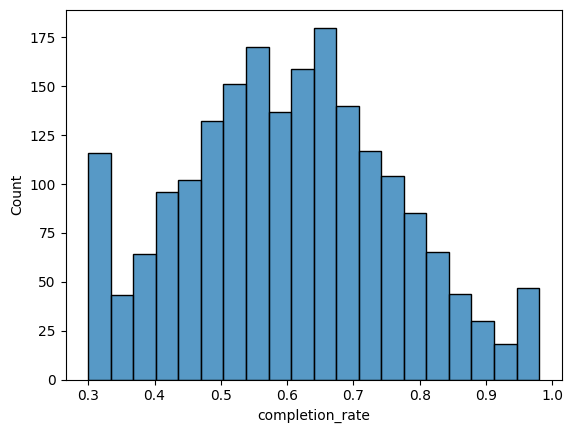

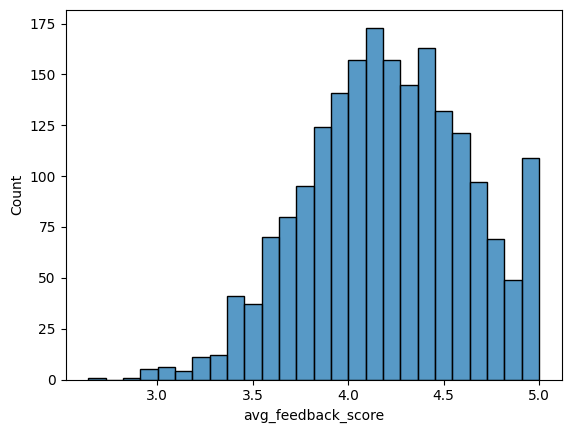

In [10]:
#Distribution Plots
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["completion_rate"])
plt.show()

sns.histplot(df["avg_feedback_score"])
plt.show()

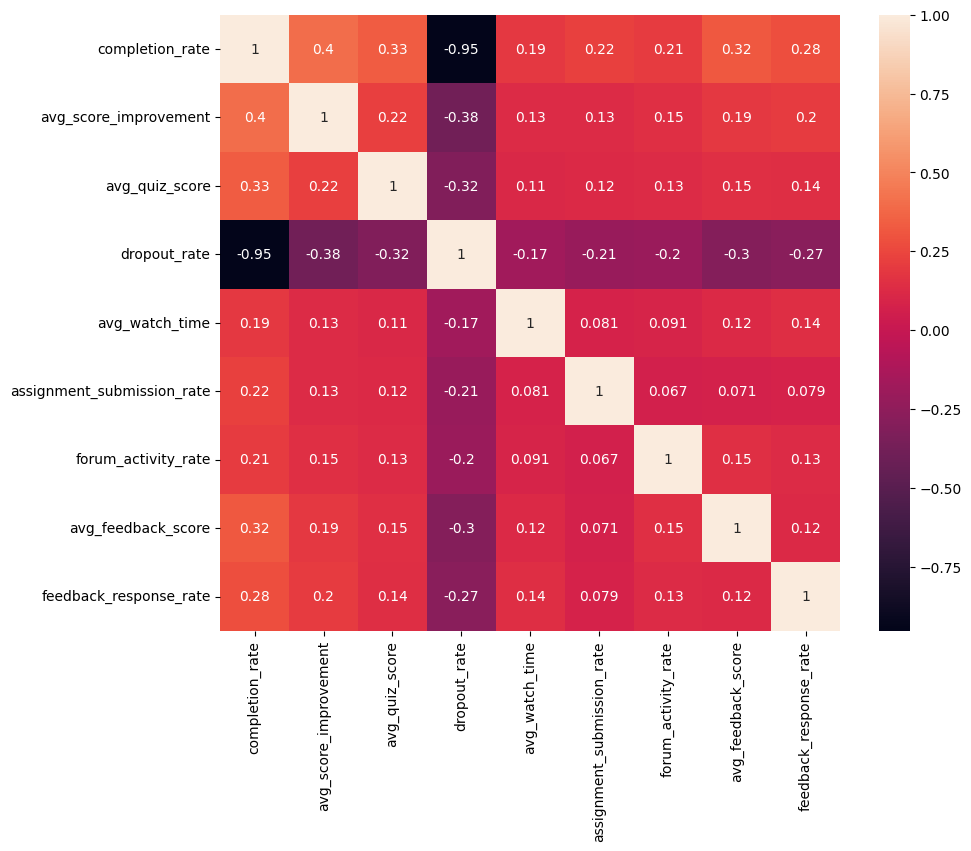

In [12]:
#Correlation Analysis
plt.figure(figsize=(10,8))
# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True)
plt.show()

Define Instructor Effectiveness Score

Effectiveness Score =

0.25 * completion_rate

0.20 * avg_score_improvement

0.15 * avg_quiz_score

0.15 * avg_watch_time

0.10 * assignment_submission_rate

0.10 * avg_feedback_score

0.05 * forum_activity_rate

In [13]:
df["effectiveness_score"] = (
0.25 * df["completion_rate"] +
0.20 * df["avg_score_improvement"] +
0.15 * df["avg_quiz_score"] +
0.15 * df["avg_watch_time"] +
0.10 * df["assignment_submission_rate"] +
0.10 * df["avg_feedback_score"] +
0.05 * df["forum_activity_rate"]
)

In [14]:
#Convert Score → Tier
def tier(score):
    if score > df["effectiveness_score"].quantile(0.66):
        return "High"
    elif score > df["effectiveness_score"].quantile(0.33):
        return "Medium"
    else:
        return "Low"

df["effectiveness_tier"] = df["effectiveness_score"].apply(tier)

Aggregate Batch Data to Instructor Level

In [15]:
instructor_df = df.groupby("instructor_id").mean(numeric_only=True).reset_index()

In [16]:
tier_map = df.groupby("instructor_id")["effectiveness_score"].mean()

instructor_df["tier"] = tier_map.apply(tier).values

Build Machine Learning Model

In [17]:
from sklearn.model_selection import train_test_split

X = instructor_df.drop(["tier","instructor_id"], axis=1)
y = instructor_df["tier"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [18]:
#Train Model


from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [19]:
#Evaluate Model
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         5
         Low       1.00      1.00      1.00         4
      Medium       1.00      1.00      1.00        15

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



Feature Importance

In [20]:
import pandas as pd

importance = pd.Series(
model.feature_importances_,
index=X.columns
)

importance.sort_values(ascending=False)

,0
effectiveness_score,0.355873
completion_rate,0.202314
dropout_rate,0.141436
avg_score_improvement,0.123066
avg_quiz_score,0.096663
avg_feedback_score,0.023810
forum_activity_rate,0.018823
feedback_response_rate,0.017120
assignment_submission_rate,0.014990
avg_watch_time,0.005906


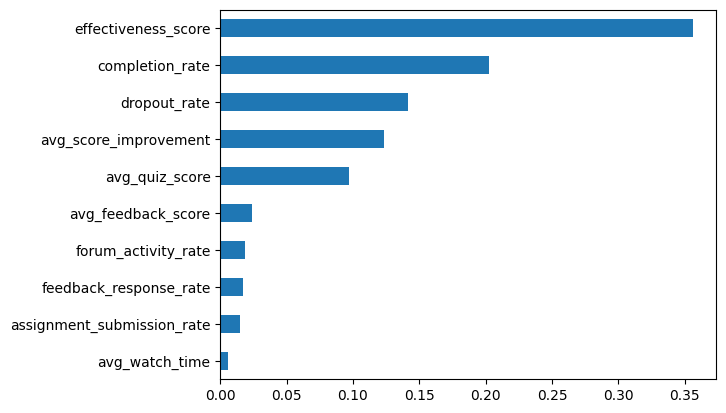

In [21]:
#Plot:

importance.sort_values().plot(kind="barh")
plt.show()

Mandatory Analysis Questions

### 1. Which features most influenced instructor effectiveness?

Completion rate, quiz score, and feedback score were the most influential features.

### 2. Which variables could be misleading?

Forum activity and dropout rate may depend on course difficulty rather than instructor quality.

### 3. How could this model fail?

The model may fail if instructors teach only a small number of batches or if feedback ratings are biased.

### 4. What additional data would improve this model?

Additional useful features include:
- Instructor teaching experience
- Course difficulty level
- Student demographics
- Live session attendance

### 5. Should this model be used for instructor evaluation?

The model should not be used as the sole evaluation tool. It should assist decision-making while considering other qualitative factors.